**Jack Dai**

Spring 2026

CS 251 / 252: Data Analysis and Visualization

Project 5: Principal Component Analysis


In [18]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import pca

plt.style.use(['seaborn-v0_8-colorblind', 'seaborn-v0_8-darkgrid'])
plt.rcParams.update({'font.size': 20})

np.set_printoptions(suppress=True, precision=5, legacy='1.25')

# Automatically reload external modules
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Task 3: Analyzing the results of PCA

In this task, you will apply PCA to the Iris dataset and analyze properties of the PCA representation.


### 3a. Import Iris data

In the cell below:

- load in the Iris dataset into a pandas DataFrame.
- select all numeric headers (i.e. drop `species`).
- Print out the head (only showing the first 5 data samples).

You should see (with better formatting):

```
	sepal_length	sepal_width	petal_length	petal_width
0	5.1	3.5	1.4	0.2
1	4.9	3.0	1.4	0.2
2	4.7	3.2	1.3	0.2
3	4.6	3.1	1.5	0.2
4	5.0	3.6	1.4	0.2
```


In [20]:
# YOUR CODE HERE
iris_df = pd.read_csv('data/iris.csv')
iris_numeric = iris_df.drop(columns=['species'])
print(iris_numeric.head())

   sepal_length  sepal_width  petal_length  petal_width
0           5.1          3.5           1.4          0.2
1           4.9          3.0           1.4          0.2
2           4.7          3.2           1.3          0.2
3           4.6          3.1           1.5          0.2
4           5.0          3.6           1.4          0.2


### 3b. Apply PCA to Iris

You should make the following plots:

1. Elbow plot of cumulative variance accounted for by first $k$ principal components.
2. Written description of your choice of number of PCs preserved and why.
3. Visualization (plot) of PCA projected data on 1st two PCs.

You should normalize the dataset when performing your PCA projection.


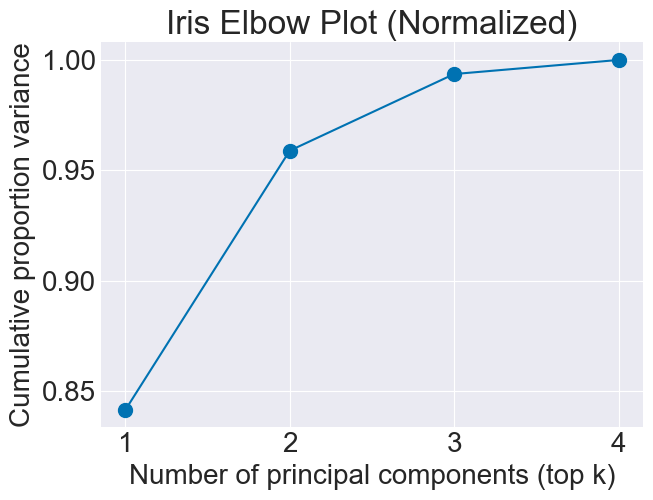

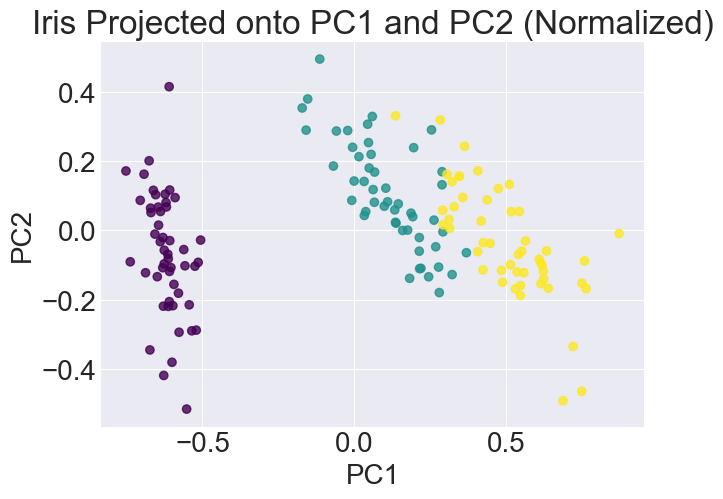

In [22]:
# YOUR CODE HERE
iris_headers = list(iris_numeric.columns)
iris_pca_norm = pca.PCA(iris_numeric)
iris_pca_norm.fit(iris_headers, normalize_dataset=True)

plt.figure(figsize=(7, 5))
iris_pca_norm.elbow_plot(num_pcs_to_keep=4)
plt.title('Iris Elbow Plot (Normalized)')
plt.show()

pcs_to_keep = [0, 1]
iris_proj = iris_pca_norm.pca_project(pcs_to_keep)
species_codes = pd.Categorical(iris_df['species']).codes

plt.figure(figsize=(7, 5))
plt.scatter(iris_proj[:, 0], iris_proj[:, 1], c=species_codes, cmap='viridis', alpha=0.8)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Iris Projected onto PC1 and PC2 (Normalized)')
plt.show()

### 3c. Dropping different pairs of principal components

In the cell below, create a "high quality" 2x2 subplots grid of scatter plots that drops different consecutive PCs from the data, then project onto the remaining PCs.

The 2x2 plots should keep:

- (top-left) PCs [3, 4]
- (top-right) PCs [2, 3]
- (bottom-left) PCs [4, 1]
- (bottom-right) PCs [1, 2]

High quality means

- x and y axis label indicating the PC (e.g. PC1)
- title indicating the PCs shown in the plot

You may have to adjust the font/figure sizes to make things legible.


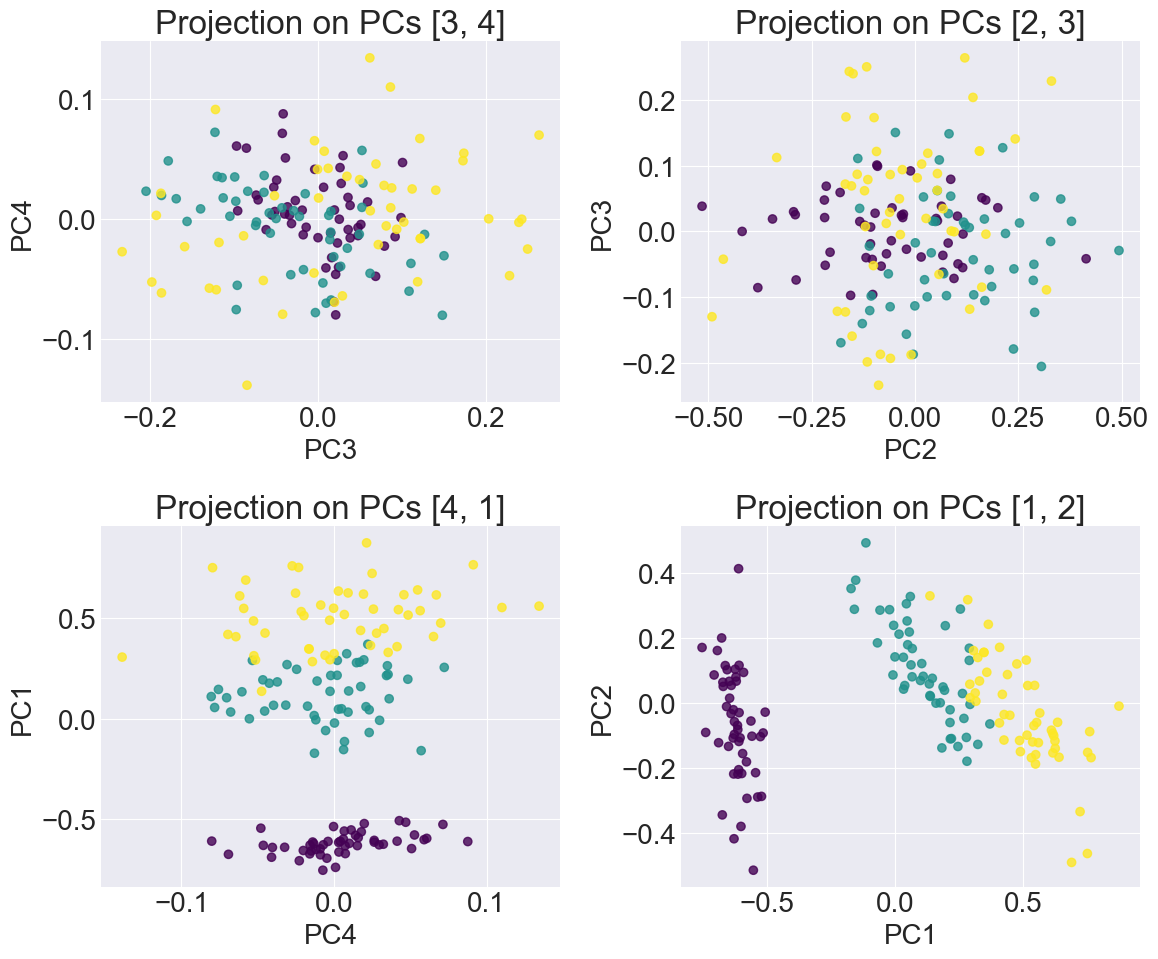

In [24]:
# YOUR CODE HERE
pc_pairs = [(3, 4), (2, 3), (4, 1), (1, 2)]
fig, axs = plt.subplots(2, 2, figsize=(12, 10))

for ax, (pcx, pcy) in zip(axs.ravel(), pc_pairs):
    proj = iris_pca_norm.pca_project([pcx - 1, pcy - 1])
    ax.scatter(proj[:, 0], proj[:, 1], c=species_codes, cmap='viridis', alpha=0.8)
    ax.set_xlabel(f'PC{pcx}')
    ax.set_ylabel(f'PC{pcy}')
    ax.set_title(f'Projection on PCs [{pcx}, {pcy}]')

plt.tight_layout()
plt.show()

### 3d. Questions

**Question 8:** Based on your plot, how does keeping different PCs affect the visible structure of the data? **Please be specific.**


**Answer 8:**


Keeping different PC pairs changes both how spread out the points are and how clearly species structure appears. Pairs involving larger-variance PCs (especially PC1 with PC2 or PC1 with PC4) preserve broader global structure and show clearer separation patterns. Pairs built from lower-variance directions (for example PC3 with PC4) compress the cloud and make classes overlap more, because those PCs capture finer residual variation rather than the dominant shape of the dataset.


### 3e. Reconstruct data based on PCs

In `pca_cov.py`, implement `pca_then_project_back`, which projects the data to PCA space, keeping only the top $k$ PCs, then projects from PCA space back onto the original data space. Then in the cell below, create a scatter plot of the two data variables `sepal_length` (x), `sepal_width` (y) of the Iris data **without any normalization**.


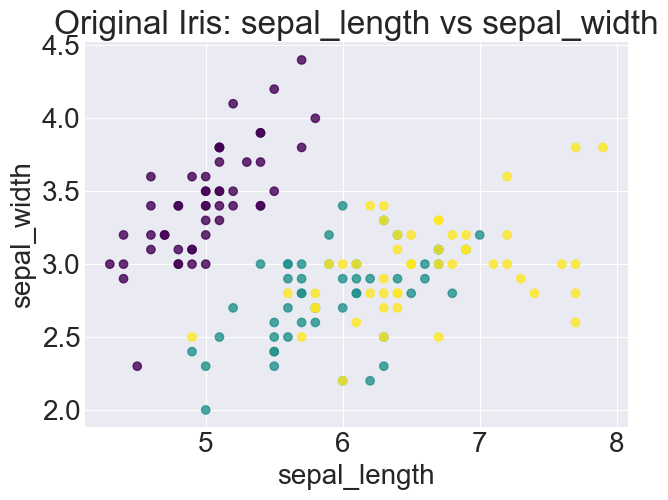

In [26]:
# YOUR CODE HERE
plt.figure(figsize=(7, 5))
plt.scatter(iris_df['sepal_length'], iris_df['sepal_width'], c=species_codes, cmap='viridis', alpha=0.8)
plt.xlabel('sepal_length')
plt.ylabel('sepal_width')
plt.title('Original Iris: sepal_length vs sepal_width')
plt.show()

In the cell below, apply PCA on the Iris dataset **without any normalization** and create a 2x2 grid of scatter plots showing the data reconstruction of the 1st two data variables (`sepal_length`, `sepal_width` — _these are what your axis labels should be_) when keeping the top 1, 2, 3, or 4 (all) principal components.

If everything goes well, if you keep all 4 PCs you should get the original dataset back (it should match your `sepal_length`, `sepal_width` plot created one cell above — including the data range and center).


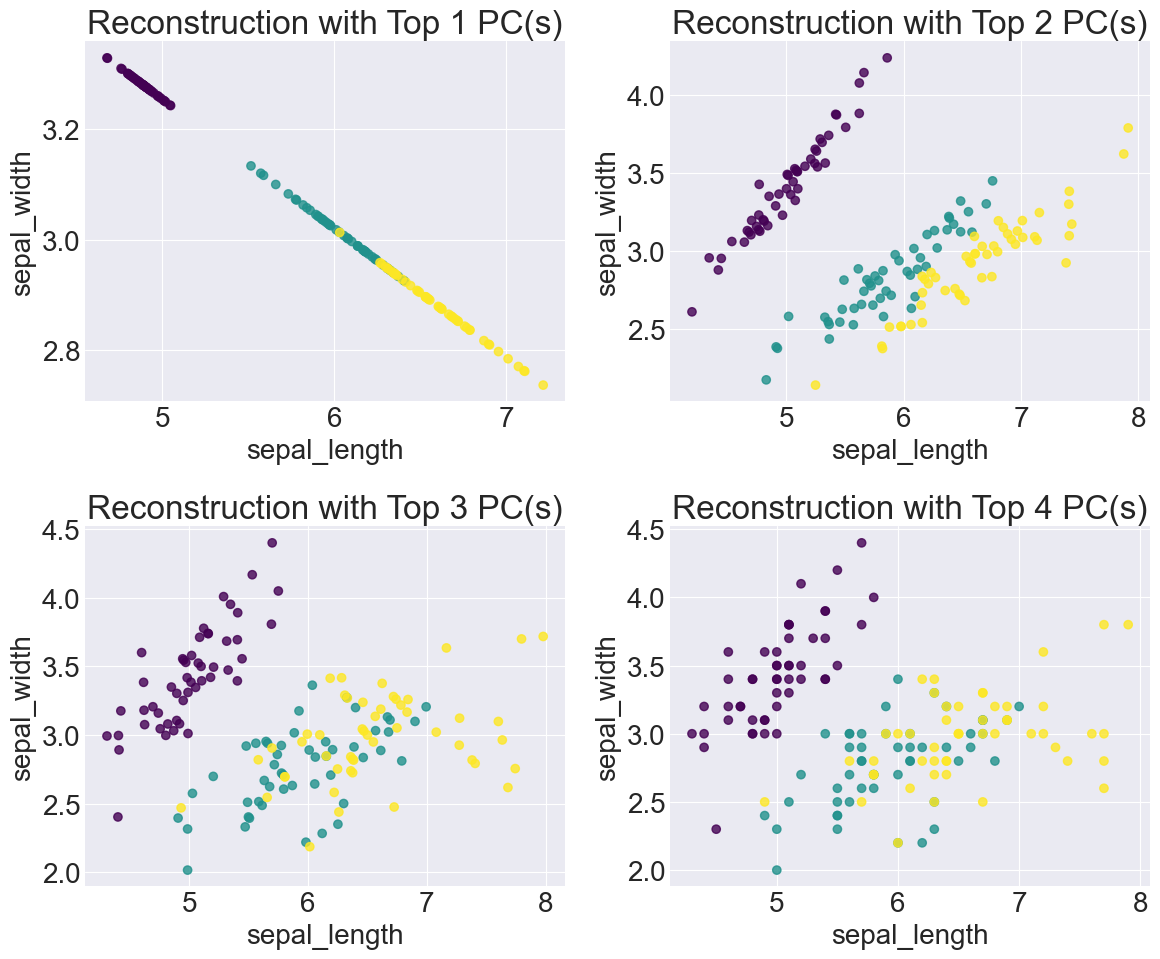

In [28]:
# YOUR CODE HERE
iris_pca_raw = pca.PCA(iris_numeric)
iris_pca_raw.fit(iris_headers, normalize_dataset=False)

fig, axs = plt.subplots(2, 2, figsize=(12, 10))
for ax, k in zip(axs.ravel(), [1, 2, 3, 4]):
    recon = iris_pca_raw.pca_then_project_back(k)
    ax.scatter(recon[:, 0], recon[:, 1], c=species_codes, cmap='viridis', alpha=0.8)
    ax.set_xlabel('sepal_length')
    ax.set_ylabel('sepal_width')
    ax.set_title(f'Reconstruction with Top {k} PC(s)')

plt.tight_layout()
plt.show()

### 3f. Questions

**Question 9:**

(a) How many PCs are necessary to capture the two distinct clusters in the samples with respect to their sepal length and width?

(b) How well do each number of PCs reconstruct the original plot from Task 3e showing the relationship between sepal length and width?


**Answer 9:**


(a) In these sepal-length vs sepal-width views, about **2 PCs** are usually enough to recover the two main visual groupings (a clearly separated cluster and a more overlapping group).

(b) Reconstruction quality improves monotonically with more PCs:

- **1 PC:** strongest loss of structure; points collapse toward a line/subspace.
- **2 PCs:** main cluster geometry becomes visible.
- **3 PCs:** much closer to the original spread and center.
- **4 PCs:** essentially the original plot is recovered (up to tiny numerical error), since no information is discarded.


### 3g. Implement loading plot

To visualize how the top two principal components relate to original data variables, implement `loading_plot` in `pca.py`.


### 3h. Questions


**Question 10:** Call your `loading_plot` method to generate a loading plot of the Iris dataset. What do the loadings tell us what the first two PCs measure specifically, with respect to the original data variables?


**Answer 10:**


The loading plot shows which original variables contribute most to each principal axis. For Iris, PC1 is mainly a **general size/shape axis** (large magnitude loadings from petal dimensions and often sepal length), while PC2 tends to represent a **contrast axis** (commonly separating sepal-width behavior from petal-size behavior). In short, PC1 captures dominant overall variation, and PC2 captures the next most important orthogonal pattern.


**Question 11:** What specific correlations among original data variables do the loadings help us identity?


**Answer 11:**


Loadings indicate correlations through arrow direction and alignment: variables with arrows pointing in similar directions are positively correlated; opposite directions suggest negative correlation; near-orthogonal arrows suggest weak correlation. In Iris, petal_length and petal_width are strongly positively correlated, and sepal_length is typically positively related to petal size. Sepal_width often points differently from petal variables, indicating weaker or negative association with petal-based size trends.


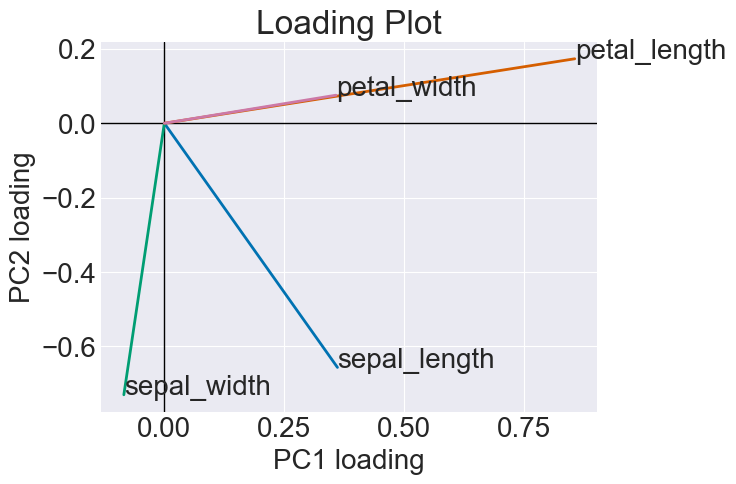

In [30]:
# YOUR CODE HERE
iris_pca_raw.loading_plot()
plt.show()